Simple Linear Regression for Rainfall-Runoff Prediction

 ## Project Introduction

Rainfall and runoff are important components of the hydrological cycle.
Understanding the relationship between rainfall and runoff can help in
water resources management and flood-related studies.

In this project, a Simple Linear Regression model is developed to examine
the relationship between rainfall and runoff and to predict runoff based
on rainfall measurements.

## Project Objective

The objective of this project is to develop and evaluate a Simple Linear
Regression model for predicting runoff from rainfall data.

### Variables

- **Independent variable (X):** Rainfall (mm)
- **Dependent variable (y):** Runoff (mm)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 3. Create the Dataset

The dataset contains rainfall measurements and their corresponding runoff values.
Rainfall will be used as the independent variable (X), while runoff will be the
dependent variable (y).

In [2]:
data = {
    "rainfall": [
        42, 55, 61, 73, 80, 92, 105, 113, 125, 137,
        145, 158, 166, 174, 185, 193, 205, 217, 225, 238,
        247, 255, 268, 276, 289, 297, 310, 322, 335, 348
    ],

    "runoff": [
        10.8, 14.2, 16.1, 19.4, 21.5, 24.8, 28.1, 29.7, 33.5, 36.2,
        39.1, 42.3, 44.8, 46.5, 50.2, 52.1, 55.7, 58.4, 60.9, 64.1,
        66.8, 69.2, 72.5, 74.9, 78.1, 80.4, 84.2, 87.1, 90.3, 93.7
    ]
}

df = pd.DataFrame(data)

df

,rainfall,runoff
0,42,10.8
1,55,14.2
2,61,16.1
3,73,19.4
4,80,21.5
5,92,24.8
6,105,28.1
7,113,29.7
8,125,33.5
9,137,36.2


In [3]:
df.shape

(30, 2)

## 4. Explore the Dataset

Before building the regression model, the dataset is examined to understand
its structure, variables, and basic statistical characteristics.

In [4]:
df.head()

,rainfall,runoff
0,42,10.8
1,55,14.2
2,61,16.1
3,73,19.4
4,80,21.5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rainfall  30 non-null     int64  
 1   runoff    30 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [6]:
df.isnull().sum()

,0
rainfall,0
runoff,0


In [7]:
df.describe()

,rainfall,runoff
count,30.000000,30.00000
mean,191.200000,51.52000
std,91.108651,24.80925
min,42.000000,10.80000
25%,116.000000,30.65000
50%,189.000000,51.15000
75%,264.750000,71.67500
max,348.000000,93.70000


## 5. Data Visualization

A scatter plot is used to visualize the relationship between rainfall and runoff.
This helps us determine whether a linear relationship appears to exist between
the two variables.

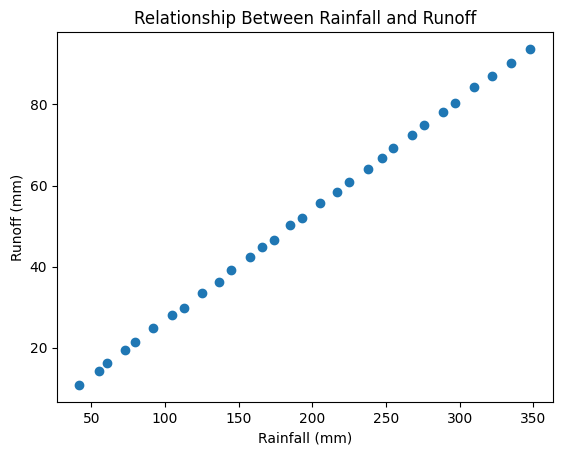

In [8]:
plt.scatter(df["rainfall"], df["runoff"])

plt.xlabel("Rainfall (mm)")
plt.ylabel("Runoff (mm)")
plt.title("Relationship Between Rainfall and Runoff")
plt.

plt.show()

In [9]:
df["rainfall"].corr(df["runoff"])

np.float64(0.9999404732793277)

## 6. Prepare the Features and Target

Rainfall is used as the independent variable (X), while runoff is used as
the dependent variable (y).

The model will learn the relationship between rainfall and runoff and use
that relationship to predict runoff.

In [10]:
X = df[["rainfall"]]
y = df["runoff"]

In [14]:
print(X.head())

print(y.head())


   rainfall
0        42
1        55
2        61
3        73
4        80
0    10.8
1    14.2
2    16.1
3    19.4
4    21.5
Name: runoff, dtype: float64


## 7. Train-Test Split

The dataset is divided into training and testing sets.

The training data is used to train the regression model, while the testing
data is kept separate and used to evaluate how well the model performs on
unseen data.

80% of the data is used for training and 20% for testing.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 24
Testing data: 6


## 8. Build the Simple Linear Regression Model

A Simple Linear Regression model is created and trained using the training
data. The model learns the relationship between rainfall and runoff.

In [19]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [20]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.2720728083507441
Intercept: -0.48654842060096115


In [21]:
y_pred = model.predict(X_test)

print(y_pred)

[87.12089587 52.02350359 74.60554668 58.55325099 33.52255262 36.78742632]


In [22]:
print(y_test.values)

[87.1 52.1 74.9 58.4 33.5 36.2]


In [23]:
comparison = pd.DataFrame({
    "Actual Runoff": y_test.values,
    "Predicted Runoff": y_pred
})

comparison

,Actual Runoff,Predicted Runoff
0,87.1,87.120896
1,52.1,52.023504
2,74.9,74.605547
3,58.4,58.553251
4,33.5,33.522553
5,36.2,36.787426


## 11. Model Evaluation — Mean Absolute Error (MAE)

Mean Absolute Error (MAE) measures the average absolute difference between
the actual runoff values and the runoff values predicted by the model.

A lower MAE indicates smaller average prediction errors.

In [24]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.19251258854085643


## 12. Mean Squared Error (MSE)

Mean Squared Error measures the average of the squared differences between
the actual and predicted runoff values.

Because the errors are squared, larger errors have a greater influence on
the MSE.

In [25]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.0770092109615931


## 13. Root Mean Squared Error (RMSE)

Root Mean Squared Error is the square root of the Mean Squared Error.
It expresses the prediction error in the same unit as the runoff data.

In [26]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE:", rmse)

RMSE: 0.27750533501464997


## 14. R-Squared (R²)

R-squared measures the proportion of the variation in runoff that is
explained by rainfall through the linear regression model.

A value closer to 1 indicates that the model explains a larger proportion
of the variation in the target variable.

In [27]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.9997934739314659


## 15. Actual vs Predicted Runoff

This plot compares the actual runoff values with the runoff values
predicted by the linear regression model.

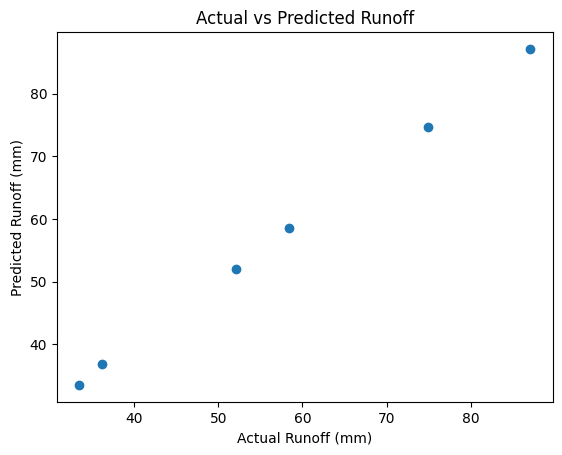

In [28]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Runoff (mm)")
plt.ylabel("Predicted Runoff (mm)")
plt.title("Actual vs Predicted Runoff")

plt.show()

## 16. Rainfall-Runoff Regression Line

This plot shows the relationship between rainfall and runoff, together
with the regression line fitted by the linear regression model.

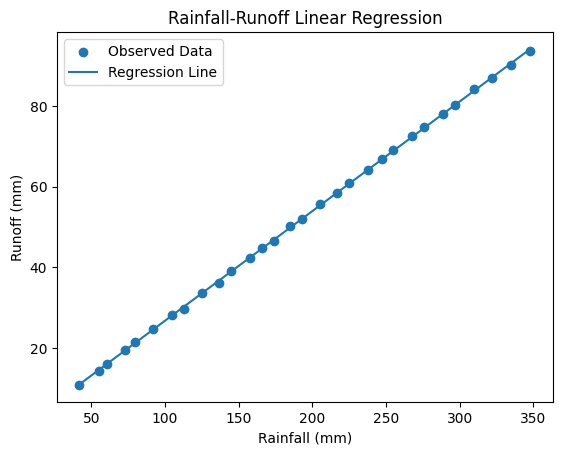

In [29]:
plt.scatter(X, y, label="Observed Data")

plt.plot(X, model.predict(X), label="Regression Line")

plt.xlabel("Rainfall (mm)")
plt.ylabel("Runoff (mm)")
plt.title("Rainfall-Runoff Linear Regression")

plt.legend()
plt.show()

## 17. Regression Equation

The linear regression model follows the equation:

Predicted Runoff = Intercept + (Coefficient × Rainfall)

The fitted equation is approximately:

Predicted Runoff = -0.487 + (0.272 × Rainfall)

The coefficient indicates the expected change in runoff for a 1 mm
increase in rainfall.

In [30]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: -0.48654842060096115
Coefficient: 0.2720728083507441


In [31]:
new_rainfall = [[250]]

predicted_runoff = model.predict(new_rainfall)

print("Predicted runoff:", predicted_runoff[0], "mm")

Predicted runoff: 67.53165366708507 mm


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 18. Residual Analysis

Residuals represent the difference between the actual runoff values and
the runoff values predicted by the model.

Residual = Actual Runoff - Predicted Runoff

Residual analysis helps us examine how the model's errors are distributed.

In [32]:
residuals = y_test - y_pred

print(residuals)

27   -0.020896
15    0.076496
23    0.294453
17   -0.153251
8    -0.022553
9    -0.587426
Name: runoff, dtype: float64


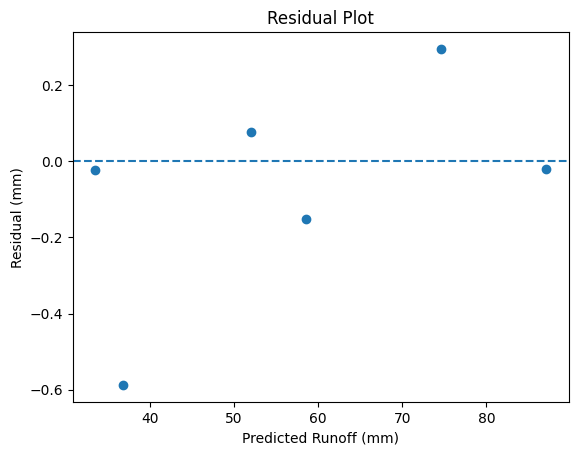

In [33]:
plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Runoff (mm)")
plt.ylabel("Residual (mm)")
plt.title("Residual Plot")

plt.show()

## 19. Model Performance Summary

The Simple Linear Regression model was evaluated using Mean Absolute Error
(MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and
R-squared (R²).

The model produced an MAE of 0.193 mm, an MSE of 0.077 mm², an RMSE of
0.278 mm, and an R² of 0.999 on the test dataset.

The results indicate that the model captures the strong linear relationship
between rainfall and runoff in this dataset.

## 20. Conclusion

This project demonstrated the use of Simple Linear Regression to predict
runoff from rainfall data.

Rainfall was used as the independent variable, while runoff was used as
the dependent variable. The dataset was divided into training and testing
sets, and the regression model was trained using the training data.

The model was evaluated using MAE, MSE, RMSE, and R². The fitted regression
equation was:

Predicted Runoff = -0.4865 + (0.2721 × Rainfall)

The model was also used to predict runoff for a new rainfall measurement
of 250 mm, producing an estimated runoff of approximately 67.53 mm.

Although the model performed very well on this practice dataset, real-world
rainfall-runoff relationships are more complex and may require additional
variables, larger datasets, and more advanced hydrological and machine
learning methods.

**Machine Learning & Data Analysis Project | Hydrology | Rainfall-Runoff Prediction**

### Author

**Jamiu Abimbola Kolawole, GMNSE**

Civil & Environmental Engineering | Data Analyst | Hydrology | Water Resources | Machine Learning